<a href="https://colab.research.google.com/github/sanmitra-b/Neural-Networks-and-Deep-Learning/blob/main/Ann_energy_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

---
## Task 1 – Data Preprocessing

### 1.1 Load the Dataset

In [ ]:
df = pd.read_csv('/content/train_energy_data.csv')

df.head(10)

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,7063,76,10,29.84,Weekday,2713.95
1,Commercial,44372,66,45,16.72,Weekday,5744.99
2,Industrial,19255,37,17,14.30,Weekend,4101.24
3,Residential,13265,14,41,32.82,Weekday,3009.14
4,Commercial,13375,26,18,11.92,Weekday,3279.17
5,Commercial,37377,26,32,16.24,Weekend,4687.67
6,Industrial,38638,92,14,21.01,Weekend,5526.83
7,Residential,34950,60,18,28.24,Weekday,4116.32
8,Industrial,29741,99,44,13.08,Weekday,5841.65
9,Residential,17467,42,36,28.84,Weekday,3419.13


### 1.2 Exploratory Data Analysis

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        1000 non-null   object 
 1   Square Footage       1000 non-null   int64  
 2   Number of Occupants  1000 non-null   int64  
 3   Appliances Used      1000 non-null   int64  
 4   Average Temperature  1000 non-null   float64
 5   Day of Week          1000 non-null   object 
 6   Energy Consumption   1000 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 54.8+ KB


In [ ]:
df.describe()

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption
count,1000.000,1000.000000,1000.000000,1000.000000,1000.000000
mean,25462.388,48.372000,25.606000,22.611390,4166.252570
std,14294.554,29.061972,14.105166,7.139943,933.313064
min,560.000,1.000000,1.000000,10.050000,1683.950000
25%,13169.750,22.000000,13.000000,16.475000,3509.482500
50%,25477.000,47.000000,26.000000,22.815000,4175.730000
75%,37446.250,73.250000,38.000000,28.850000,4863.850000
max,49997.000,99.000000,49.000000,34.990000,6530.600000


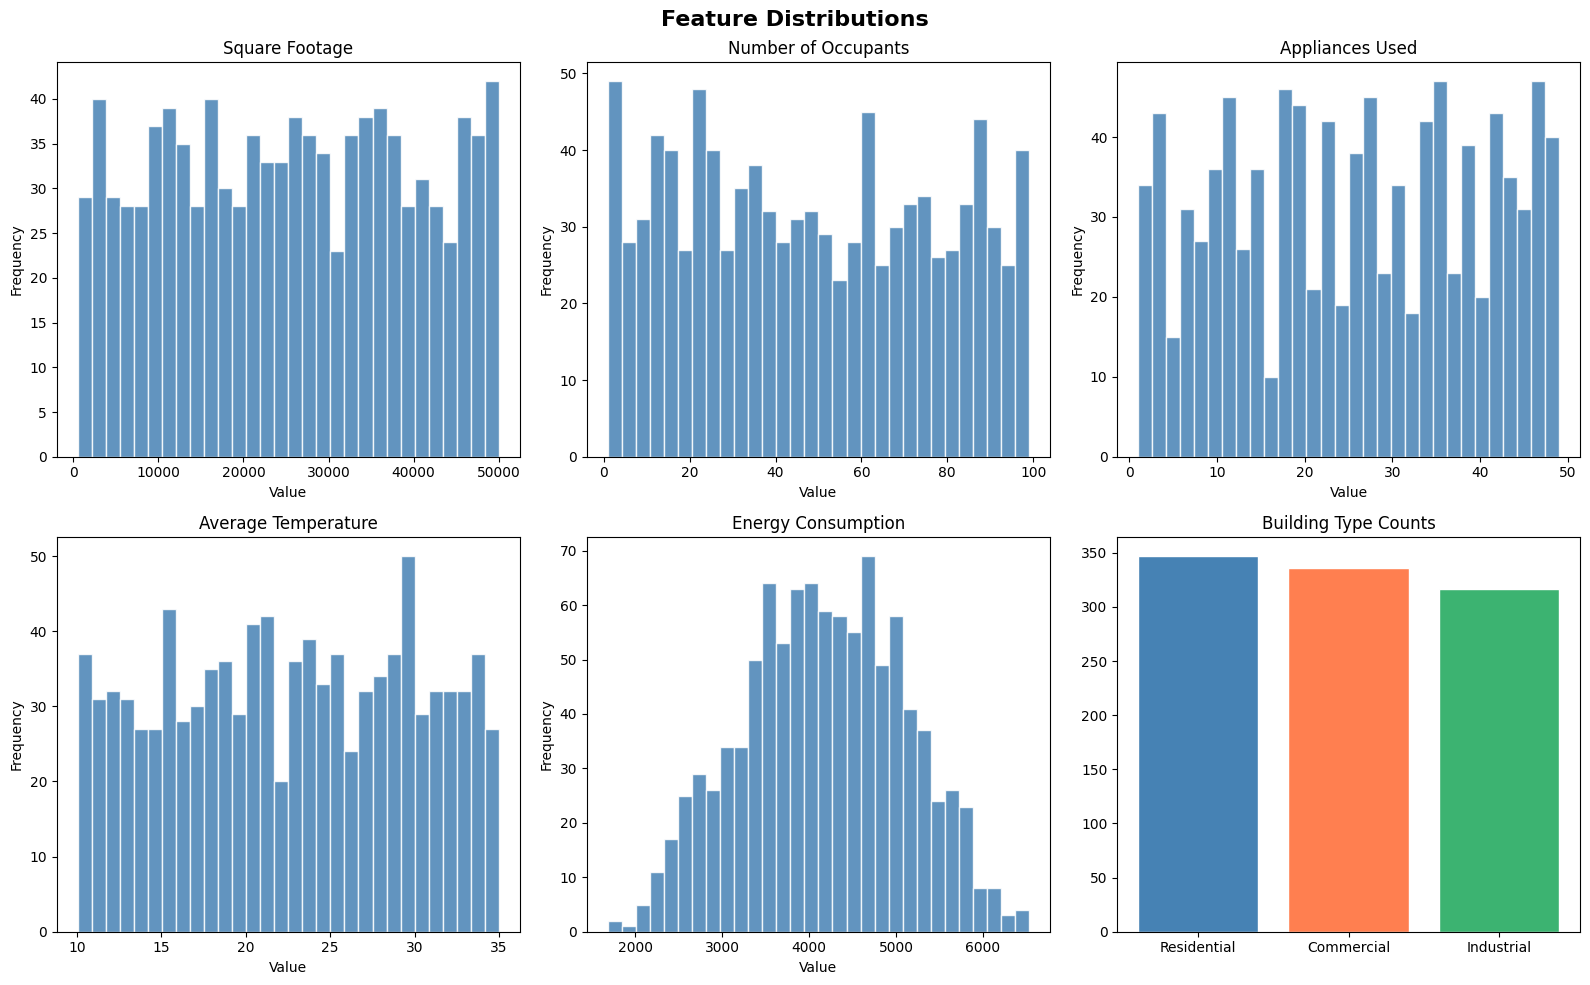

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Feature Distributions', fontsize=16, fontweight='bold')

num_cols = ['Square Footage', 'Number of Occupants', 'Appliances Used',
            'Average Temperature', 'Energy Consumption']

for i, col in enumerate(num_cols):
    r, c = divmod(i, 3)
    axes[r, c].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[r, c].set_title(col)
    axes[r, c].set_xlabel('Value')
    axes[r, c].set_ylabel('Frequency')

# Category counts in the last cell
axes[1, 2].bar(df['Building Type'].value_counts().index,
               df['Building Type'].value_counts().values,
               color=['steelblue', 'coral', 'mediumseagreen'], edgecolor='white')
axes[1, 2].set_title('Building Type Counts')

plt.tight_layout()
plt.show()

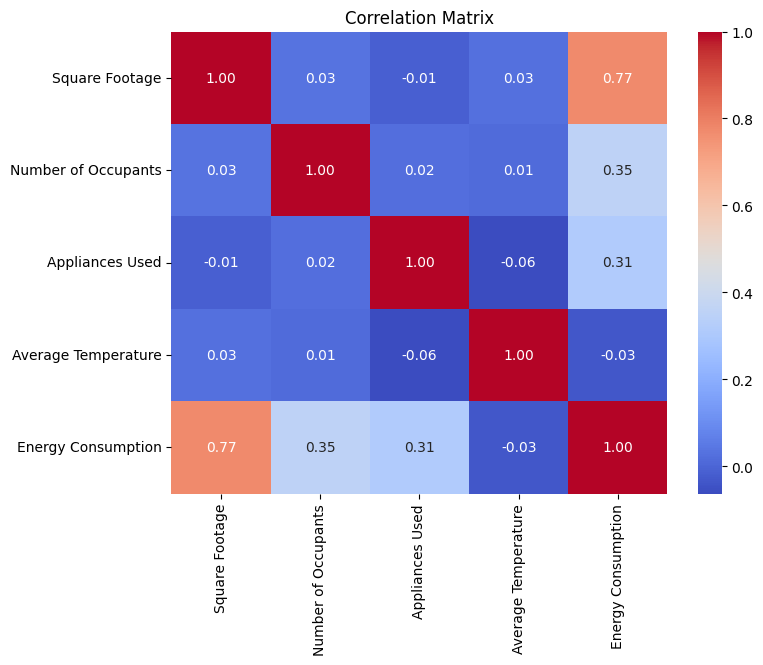

In [ ]:
# Correlation heatmap (numeric columns)
correlation=df.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

### 1.3 Handle Missing Values

In [ ]:
df.isnull().sum()


,0
Building Type,0
Square Footage,0
Number of Occupants,0
Appliances Used,0
Average Temperature,0
Day of Week,0
Energy Consumption,0


In [ ]:
df.duplicated().sum()

np.int64(0)

### 1.4 Feature Engineering & Encoding

In [ ]:
df_enc = df.copy()

# Label-encode binary column
df_enc['Day of Week'] = (df_enc['Day of Week'] == 'Weekend').astype(int)

# One-hot encode Building Type (drop_first avoids dummy-variable trap)
df_enc = pd.get_dummies(df_enc, columns=['Building Type'], drop_first=False)

print('Encoded columns:', df_enc.columns.tolist())
df_enc.head(3)

Encoded columns: ['Square Footage', 'Number of Occupants', 'Appliances Used', 'Average Temperature', 'Day of Week', 'Energy Consumption', 'Building Type_Commercial', 'Building Type_Industrial', 'Building Type_Residential']


,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption,Building Type_Commercial,Building Type_Industrial,Building Type_Residential
0,7063,76,10,29.84,0,2713.95,False,False,True
1,44372,66,45,16.72,0,5744.99,True,False,False
2,19255,37,17,14.30,1,4101.24,False,True,False


### 1.5 Normalize Input Features & Split Dataset

In [ ]:
TARGET = 'Energy Consumption'
FEATURES = [c for c in df_enc.columns if c != TARGET]

X = df_enc[FEATURES].values.astype(np.float32)
y = df_enc[TARGET].values.astype(np.float32)

# 70 / 15 / 15 split  →  train / val / test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED)

# Fit scaler ONLY on training data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f'Training set   : {X_train.shape[0]} samples')
print(f'Validation set : {X_val.shape[0]} samples')
print(f'Test set       : {X_test.shape[0]} samples')
print(f'Number of features : {X_train.shape[1]}')

---
## Task 2 – Building the ANN

In [ ]:
def build_ann(input_dim, hidden_layers, optimizer='adam', learning_rate=0.001):
    """
    Builds a regression ANN.

    Parameters
    ----------
    input_dim     : int   – number of input features
    hidden_layers : list  – list of neuron counts per hidden layer, e.g. [64, 32]
    optimizer     : str   – 'adam' or 'sgd'
    learning_rate : float – learning rate

    Returns
    -------
    Compiled keras.Sequential model
    """
    model = keras.Sequential(name='ANN_Regression')

    # ── Input layer ─────────────────────────────────────────────────────────
    model.add(layers.Input(shape=(input_dim,), name='input_layer'))

    # ── Hidden layers (ReLU activation) ─────────────────────────────────────
    for i, units in enumerate(hidden_layers):
        model.add(layers.Dense(units, activation='relu',
                               name=f'hidden_{i+1}'))
        model.add(layers.BatchNormalization(name=f'bn_{i+1}'))
        model.add(layers.Dropout(0.1, name=f'dropout_{i+1}'))

    # ── Output layer (Linear / no activation) ───────────────────────────────
    model.add(layers.Dense(1, activation='linear', name='output_layer'))

    return model


INPUT_DIM = X_train.shape[1]

# Default model: 2 hidden layers  [128, 64]
model = build_ann(INPUT_DIM, hidden_layers=[128, 64])
model.summary()

---
## Task 3 – Compiling the ANN

In [ ]:
def compile_model(model, optimizer_name='adam', learning_rate=0.001):
    """Compile with MSE loss; track MAE and RMSE during training."""
    if optimizer_name.lower() == 'adam':
        opt = keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name.lower() == 'sgd':
        opt = keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9)
    else:
        raise ValueError(f'Unknown optimizer: {optimizer_name}')

    model.compile(
        optimizer=opt,
        loss='mean_squared_error',          # Task 3 requirement
        metrics=['mae',
                 keras.metrics.RootMeanSquaredError(name='rmse')]
    )
    return model

model = compile_model(model, optimizer_name='adam', learning_rate=0.001)
print('Model compiled successfully.')

---
## Task 4 – Training the ANN

In [ ]:
EPOCHS     = 150
BATCH_SIZE = 32

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=15,
        restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=7, verbose=1)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

print(f'\nTraining stopped at epoch {len(history.history["loss"])}')

### 4.1 Training & Validation Loss Curves

In [ ]:
def plot_loss_curves(history, title_suffix=''):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Training Curves {title_suffix}', fontsize=14, fontweight='bold')

    # MSE loss
    axes[0].plot(history.history['loss'],     label='Train MSE', color='steelblue')
    axes[0].plot(history.history['val_loss'], label='Val MSE',   color='coral', linestyle='--')
    axes[0].set_title('Loss (MSE) vs Epochs')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MSE')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # MAE
    axes[1].plot(history.history['mae'],     label='Train MAE', color='mediumseagreen')
    axes[1].plot(history.history['val_mae'], label='Val MAE',   color='tomato', linestyle='--')
    axes[1].set_title('MAE vs Epochs')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_loss_curves(history, title_suffix='(Default Model – Adam, LR=0.001)')

---
## Task 5 – Evaluating the ANN

### 5.1 Metrics on Test Set

In [ ]:
def evaluate_model(model, X_test, y_test, label='Model'):
    """Compute and print MAE, MSE, RMSE, R²."""
    y_pred = model.predict(X_test, verbose=0).flatten()

    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)

    print(f'┌─────────────────────────────────────────┐')
    print(f'│  Evaluation Results – {label:<17}│')
    print(f'├─────────────────────────────────────────┤')
    print(f'│  MAE  : {mae:>10.4f}                    │')
    print(f'│  MSE  : {mse:>10.4f}                    │')
    print(f'│  RMSE : {rmse:>10.4f}                    │')
    print(f'│  R²   : {r2:>10.4f}                    │')
    print(f'└─────────────────────────────────────────┘')

    return y_pred, {'label': label, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}


y_pred_default, metrics_default = evaluate_model(model, X_test, y_test,
                                                  label='Default (Adam)')

### 5.2 Actual vs Predicted Values

In [ ]:
def plot_actual_vs_predicted(y_test, y_pred, title=''):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Actual vs Predicted – {title}', fontsize=14, fontweight='bold')

    # Scatter plot
    axes[0].scatter(y_test, y_pred, alpha=0.5, color='steelblue', edgecolors='white', s=30)
    lims = [min(y_test.min(), y_pred.min()) - 100,
            max(y_test.max(), y_pred.max()) + 100]
    axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect Prediction')
    axes[0].set_xlim(lims); axes[0].set_ylim(lims)
    axes[0].set_xlabel('Actual Energy Consumption (kWh)')
    axes[0].set_ylabel('Predicted Energy Consumption (kWh)')
    axes[0].set_title('Actual vs Predicted')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Line plot (first 60 samples)
    n = min(60, len(y_test))
    idx = np.arange(n)
    axes[1].plot(idx, y_test[:n],  label='Actual',    color='steelblue', linewidth=1.5)
    axes[1].plot(idx, y_pred[:n],  label='Predicted', color='coral',     linewidth=1.5, linestyle='--')
    axes[1].set_xlabel('Sample Index')
    axes[1].set_ylabel('Energy Consumption (kWh)')
    axes[1].set_title('First 60 Test Samples')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_actual_vs_predicted(y_test, y_pred_default, title='Default Model')

### 5.3 Residual Error Analysis

In [ ]:
def plot_residuals(y_test, y_pred, title=''):
    residuals = y_test - y_pred

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Residual Analysis – {title}', fontsize=14, fontweight='bold')

    # Residuals vs Predicted
    axes[0].scatter(y_pred, residuals, alpha=0.5, color='slateblue', edgecolors='white', s=30)
    axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
    axes[0].set_xlabel('Predicted Values')
    axes[0].set_ylabel('Residuals')
    axes[0].set_title('Residuals vs Predicted')
    axes[0].grid(True, alpha=0.3)

    # Residual distribution
    axes[1].hist(residuals, bins=30, color='teal', edgecolor='white', alpha=0.85)
    axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
    axes[1].set_xlabel('Residual')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Residual Distribution')
    axes[1].grid(True, alpha=0.3)

    # Cumulative residuals
    sorted_res = np.sort(np.abs(residuals))
    cdf = np.arange(1, len(sorted_res)+1) / len(sorted_res)
    axes[2].plot(sorted_res, cdf, color='darkorange', linewidth=2)
    axes[2].set_xlabel('|Residual|')
    axes[2].set_ylabel('Cumulative Probability')
    axes[2].set_title('CDF of Absolute Residuals')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    print(f'Residual mean  : {residuals.mean():.4f}')
    print(f'Residual std   : {residuals.std():.4f}')
    print(f'Max |residual| : {np.abs(residuals).max():.4f}')

plot_residuals(y_test, y_pred_default, title='Default Model')

---
## Task 6 – Experimental Analysis

We train multiple ANN variants and compare them on the test set.

| Experiment | Optimizer | LR     | Hidden Layers | Batch Size |
|------------|-----------|--------|---------------|------------|
| A (default)| Adam      | 0.001  | [128, 64]     | 32         |
| B          | Adam      | 0.0001 | [128, 64]     | 32         |
| C          | SGD       | 0.01   | [128, 64]     | 32         |
| D          | Adam      | 0.001  | [64]          | 32         |
| E          | Adam      | 0.001  | [256, 128, 64]| 32         |
| F          | Adam      | 0.001  | [128, 64]     | 16         |
| G          | Adam      | 0.001  | [128, 64]     | 64         |

In [ ]:
EXPERIMENTS = [
    {'label': 'A – Default (Adam 0.001, [128,64], bs=32)',
     'optimizer': 'adam',  'lr': 0.001,  'layers': [128, 64],      'batch': 32},
    {'label': 'B – Low LR  (Adam 0.0001, [128,64], bs=32)',
     'optimizer': 'adam',  'lr': 0.0001, 'layers': [128, 64],      'batch': 32},
    {'label': 'C – SGD     (SGD 0.01,   [128,64], bs=32)',
     'optimizer': 'sgd',   'lr': 0.01,   'layers': [128, 64],      'batch': 32},
    {'label': 'D – Shallow  (Adam 0.001, [64],    bs=32)',
     'optimizer': 'adam',  'lr': 0.001,  'layers': [64],           'batch': 32},
    {'label': 'E – Deep     (Adam 0.001, [256,128,64], bs=32)',
     'optimizer': 'adam',  'lr': 0.001,  'layers': [256, 128, 64], 'batch': 32},
    {'label': 'F – Small BS (Adam 0.001, [128,64], bs=16)',
     'optimizer': 'adam',  'lr': 0.001,  'layers': [128, 64],      'batch': 16},
    {'label': 'G – Large BS (Adam 0.001, [128,64], bs=64)',
     'optimizer': 'adam',  'lr': 0.001,  'layers': [128, 64],      'batch': 64},
]

results = []
all_histories = []

for exp in EXPERIMENTS:
    print(f"\n{'='*60}")
    print(f"  Running: {exp['label']}")
    print(f"{'='*60}")

    m = build_ann(INPUT_DIM,
                  hidden_layers=exp['layers'])
    m = compile_model(m,
                      optimizer_name=exp['optimizer'],
                      learning_rate=exp['lr'])

    cb = [
        keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=15,
            restore_best_weights=True, verbose=0),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=7, verbose=0)
    ]

    h = m.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=150,
        batch_size=exp['batch'],
        callbacks=cb,
        verbose=0
    )

    y_pred_exp = m.predict(X_test, verbose=0).flatten()
    mae  = mean_absolute_error(y_test, y_pred_exp)
    mse  = mean_squared_error(y_test, y_pred_exp)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred_exp)
    epochs_run = len(h.history['loss'])

    results.append({
        'Experiment': exp['label'],
        'MAE': round(mae, 4),
        'MSE': round(mse, 4),
        'RMSE': round(rmse, 4),
        'R²': round(r2, 4),
        'Epochs Run': epochs_run
    })
    all_histories.append(h)

    print(f'  MAE={mae:.2f}  MSE={mse:.2f}  RMSE={rmse:.2f}  R²={r2:.4f}  '
          f'Epochs={epochs_run}')

print("\n✔ All experiments complete.")

### 6.1 Comparison Table

In [ ]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R²', ascending=False).reset_index(drop=True)
results_df.index += 1   # 1-based ranking
results_df.index.name = 'Rank'

print('\n=== Experiment Comparison (sorted by R² descending) ===')
pd.set_option('display.max_colwidth', 60)
display(results_df)

### 6.2 Performance Metric Comparison Charts

In [ ]:
exp_labels = [f"Exp {chr(65+i)}" for i in range(len(EXPERIMENTS))]
orig_df    = pd.DataFrame(results)   # keep original order for bar charts

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Experimental Comparison of ANN Configurations', fontsize=15, fontweight='bold')

colors = plt.cm.tab10(np.linspace(0, 1, len(exp_labels)))

for ax, metric in zip(axes.flat, ['MAE', 'MSE', 'RMSE', 'R²']):
    bars = ax.bar(exp_labels, orig_df[metric], color=colors, edgecolor='white', width=0.6)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.set_xlabel('Experiment')
    ax.tick_params(axis='x', rotation=15)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, orig_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (orig_df[metric].max() * 0.01),
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

### 6.3 Training Loss Curves – All Experiments

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle('Validation Loss per Experiment', fontsize=14, fontweight='bold')

for i, (h, exp) in enumerate(zip(all_histories, EXPERIMENTS)):
    ax = axes[i // 4][i % 4]
    ax.plot(h.history['loss'],     label='Train', color='steelblue')
    ax.plot(h.history['val_loss'], label='Val',   color='coral', linestyle='--')
    ax.set_title(f'Exp {chr(65+i)}', fontsize=9)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

# hide the last (empty) axes slot
axes[1][3].set_visible(False)
plt.tight_layout()
plt.show()

### 6.4 Best Model – Final Evaluation

In [ ]:
best_idx  = orig_df['R²'].idxmax()          # 0-based index into EXPERIMENTS list
best_exp  = EXPERIMENTS[best_idx]
best_row  = orig_df.iloc[best_idx]

print('='*55)
print('  BEST-PERFORMING MODEL')
print('='*55)
print(f"  Configuration : {best_exp['label']}")
print(f"  Optimizer     : {best_exp['optimizer'].upper()}")
print(f"  Learning Rate : {best_exp['lr']}")
print(f"  Hidden Layers : {best_exp['layers']}")
print(f"  Batch Size    : {best_exp['batch']}")
print('-'*55)
print(f"  MAE  : {best_row['MAE']:.4f}")
print(f"  MSE  : {best_row['MSE']:.4f}")
print(f"  RMSE : {best_row['RMSE']:.4f}")
print(f"  R²   : {best_row['R²']:.4f}")
print('='*55)

# Re-train the best model for full evaluation plots
best_model = build_ann(INPUT_DIM, hidden_layers=best_exp['layers'])
best_model = compile_model(best_model, optimizer_name=best_exp['optimizer'],
                           learning_rate=best_exp['lr'])

best_history = best_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=best_exp['batch'],
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=15,
            restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=7, verbose=0)
    ],
    verbose=1
)

In [ ]:
y_pred_best, _ = evaluate_model(best_model, X_test, y_test,
                                 label=f"Best – Exp {chr(65+best_idx)}")
plot_loss_curves(best_history, title_suffix=f'(Best Model – Exp {chr(65+best_idx)})')
plot_actual_vs_predicted(y_test, y_pred_best, title=f'Best Model – Exp {chr(65+best_idx)}')
plot_residuals(y_test, y_pred_best, title=f'Best Model – Exp {chr(65+best_idx)}')

---
## Summary

| Section | What was done |
|---------|---------------|
| Task 1 | Loaded 1 000-row Energy Consumption dataset; EDA with histograms, box plots, correlation heatmap; confirmed zero missing values; label-encoded `Day of Week`; one-hot encoded `Building Type`; normalized with `StandardScaler`; split 70/15/15. |
| Task 2 | Built `Sequential` ANN with configurable hidden layers (ReLU), BatchNorm, Dropout, and a single linear output neuron. |
| Task 3 | Compiled with MSE loss; tracked MAE and RMSE; tested both Adam and SGD optimizers. |
| Task 4 | Trained with EarlyStopping and ReduceLROnPlateau; plotted training/validation loss & MAE curves. |
| Task 5 | Evaluated on hold-out test set: MAE, MSE, RMSE, R²; plotted Actual vs Predicted scatter + line, and full residual analysis (scatter, histogram, CDF). |
| Task 6 | Ran 7 experiments varying optimizer, learning rate, architecture depth, and batch size; compared all metrics in a table and bar charts; identified and fully evaluated the best-performing configuration. |